In [2]:
# The line below allows to print all the outputs of a cell instead of only the last one
# %config InteractiveShell.ast_node_interactivity = "all"
import os
import pathlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

In [24]:
from_script = False

print(f"WARNING: This notebook is set with from_script = {from_script}.")

if from_script:
    # Get the path of the notebook config file from the environment variable
    path_config_notebook = os.environ["PATH_YAML_CONFIG"]
    # Load the notebook config file
    with open(path_config_notebook, "r") as file:
        dict_config_notebook = yaml.safe_load(file)
        print("The dict_config_notebook is:")
        print(dict_config_notebook)
    ID_XP_DATASET = dict_config_notebook["id_xp_dataset"]
    ID_XP = dict_config_notebook["id_xp"]
    PATH_PROJECT = pathlib.Path(dict_config_notebook["path_project"])
    DICT_FILTERS = dict_config_notebook.get("dict_filters", None)
    NAME_SEABORN_COLUMN = dict_config_notebook.get("name_seaborn_column", "delay_obs")
    NAME_SEABORN_ROW = dict_config_notebook.get("name_seaborn_row", "env_name")
    NAME_SEABORN_HUE = dict_config_notebook.get("name_seaborn_hue", "trainer_name")
    NAME_COLUMN_TO_LOOP_OVER = dict_config_notebook.get(
        "column_to_loop_over", "env_params_mesh"
    )
    NAME_MLFLOW_STORE = dict_config_notebook.get(
        "name_mlflow_store", "mlruns_ruche_downloaded"
    )

    DEBUG_SIZE_FILTER = dict_config_notebook.get("debug_size_filter", None)
else:
    ID_XP_DATASET = 21
    ID_XP = 24
    PATH_PROJECT = pathlib.Path(
        "/home/hosseinkhan/Documents/work/phd/git_repositories/control_dde"
    )
    # DICT_FILTERS = {
    #     "env_name": ["cylinder"],
    #     "env_params_max_control": [0.0],
    #     "env_params_reynolds": [120.0, 90.0],
    # }
    DICT_FILTERS = {}
    DEBUG_SIZE_FILTER = None
    assert (
        DEBUG_SIZE_FILTER is None or DEBUG_SIZE_FILTER > 0
    ), "DEBUG_SIZE_FILTER must be positive."

    # DICT_FILTERS = None
    NAME_SEABORN_COLUMN = "env_params_max_control"
    NAME_SEABORN_ROW = "env_params_reynolds"
    NAME_SEABORN_HUE = "trainer_name"
    NAME_COLUMN_TO_LOOP_OVER = "env_name"
    NAME_MLFLOW_STORE = "mlruns_ruche_downloaded"

# Add the path of the project to the sys.path in order to import
# the modules in the src folder
sys.path.insert(0, os.path.abspath(PATH_PROJECT))

# Define the paths
path_mlruns = pathlib.Path(f"{PATH_PROJECT}/data/{NAME_MLFLOW_STORE}")
path_experiment_dataset = pathlib.Path(f"{path_mlruns}/{ID_XP_DATASET}")
path_experiment = pathlib.Path(f"{path_mlruns}/{ID_XP}")
# Get all folder in the mlruns/id_xp directory except the folder 'tags'
# using pathlib and iter dir
list_id_hash = [
    path.name
    for path in path_experiment.iterdir()
    if path.is_dir() and path.name != "tags"
]
list_id_hash_dataset = [
    path.name
    for path in path_experiment_dataset.iterdir()
    if path.is_dir() and path.name != "tags"
]

print(f"Number of runs in the dataset: {len(list_id_hash_dataset)} \n")
print(f"Number of runs: {len(list_id_hash)} \n")
print(f"XP id dataset: {ID_XP_DATASET} \n")
print(f"XP id: {ID_XP} \n")

nested_dict_config_dataset = {}
nested_dict_config = {}
list_df_config_flattened_dataset = []
list_df_config_flattened = []


def check_xp_lifecycle(path_file: pathlib.Path):
    if not path_file.exists():
        raise FileNotFoundError(f"The file {path_file} does not exist.")
    if not path_file.is_file():
        raise FileNotFoundError(f"The path {path_file} is not a file.")
    # Load the yaml file
    with open(path_file, "r") as _file:
        dict_temp = yaml.safe_load(_file)
    # Check the lifecycle key
    assert dict_temp.get("lifecycle_stage") == "active", "The experiment is not active."


# Verify all experiments are done on the same environment:
path_xp = f"{path_mlruns}/{ID_XP}"
for name_id in list_id_hash:
    # Check file lifecycle
    list_glob_xp_metadata = list(pathlib.Path(f"{path_xp}/{name_id}").glob("meta.yaml"))
    assert len(list_glob_xp_metadata) != 0, "No metadata file in the directory."
    assert (
        len(list_glob_xp_metadata) == 1
    ), "More than one metadata file in the directory."
    check_xp_lifecycle(list_glob_xp_metadata[0])

    # Get the config file
    list_glob_config = list(
        pathlib.Path(f"{path_xp}/{name_id}/artifacts").glob("./config/*.yaml")
    )
    assert len(list_glob_config) != 0, "No config file in the directory."
    assert len(list_glob_config) == 1, "More than one config file in the directory."

    name_config_file = list_glob_config[0].name
    # Check if the file is a yaml file
    assert name_config_file.endswith(".yaml"), "File is not a yaml file."

    path_run_config_yaml = list_glob_config[0]
    with open(path_run_config_yaml, "r") as file:
        # Get the config file as a dictionary
        dict_config_temp = yaml.safe_load(file)
        # Add the config file to the nested dictionary
        nested_dict_config[name_id] = dict_config_temp
        # Flatten the config file for easier check
        list_df_config_flattened.append(pd.json_normalize(dict_config_temp, sep="_"))
    del dict_config_temp

path_xp_dataset = f"{path_mlruns}/{ID_XP_DATASET}"
for name_id in list_id_hash_dataset:
    list_glob_config = list(
        pathlib.Path(f"{path_xp_dataset}/{name_id}/generated_data").glob(
            "./config/*.yaml"
        )
    )
    assert len(list_glob_config) != 0, "No config file in the directory."
    assert len(list_glob_config) == 1, "More than one config file in the directory."

    name_config_file = list_glob_config[0].name
    # Check if the file is a yaml file
    assert name_config_file.endswith(".yaml"), "File is not a yaml file."

    path_run_config_yaml = list_glob_config[0]
    with open(path_run_config_yaml, "r") as file:
        # Get the config file as a dictionary
        dict_config_temp = yaml.safe_load(file)
        # Add the config file to the nested dictionary
        nested_dict_config_dataset[name_id] = dict_config_temp
        # Flatten the config file for easier check
        list_df_config_flattened_dataset.append(
            pd.json_normalize(dict_config_temp, sep="_")
        )
    del dict_config_temp

Number of runs in the dataset: 22 

Number of runs: 176 

XP id dataset: 21 

XP id: 24 



## DataFrames generation

### DataFrame: Training config

In [4]:
df_trainining_config = (
    pd.concat(
        [
            df_config_flattened.assign(training_id=name_id)
            for name_id, df_config_flattened in zip(
                list_id_hash, list_df_config_flattened
            )
        ]
    )
    .set_index("training_id")
    .pipe(
        lambda df: df.astype(
            {col: "float" for col in df.select_dtypes(include="int").columns}
        )
    )
)

df_trainining_config.head(10)

,mlflow_experiment_name,seed,data_normaliser_name,data_path_data_folder,model_name,model_params_activation,model_params_delay_exponential_dist_param,model_params_depth,model_params_dropout,model_params_final_activation,...,trainer_name,trainer_params_bool_discretize_then_optimize,trainer_params_lr_final,trainer_params_lr_init,trainer_params_max_epochs,trainer_params_name_node_interface,trainer_params_pct_trajectory_size,trainer_params_rate_test_set_size,trainer_params_solver,model_params_n_delays
training_id,,,,,,,,,,,,,,,,,,,,,
f49eee38fc7f49e2b7b99d7880530f80,2024_11_27_training_00h_04m,0.0,standard_normal,data/mlruns/21/331afa8c845f4bc295b05a7d4ec716e...,ncde,relu,5.0,2.0,0.0,identity,...,ncde,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,NaN
0abed15ee28c44e4ae29149d1431efa0,2024_11_27_training_00h_04m,0.0,standard_normal,data/mlruns/21/4e27a8e7a9c24b70acf9ba88d538cfc...,node,relu,5.0,2.0,0.0,identity,...,node,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,NaN
5fdfd5942e6e4c80a2a75e4eae5131e5,2024_11_27_training_00h_04m,0.0,standard_normal,data/mlruns/21/4bbd8db9115d46c1bf2805c7718ac1c...,ndde,relu,5.0,2.0,0.0,identity,...,ndde,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,1.0
da38baa85d514f79955666a12c97e2e4,2024_11_27_training_00h_04m,1.0,standard_normal,data/mlruns/21/30cf92b2bedb4adf92c965923008947...,ncde,relu,5.0,2.0,0.0,identity,...,ncde,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,NaN
4459de875178471c9166160b89154651,2024_11_27_training_00h_04m,1.0,standard_normal,data/mlruns/21/ea32766566804a7e94de4ec18042b53...,node,relu,5.0,2.0,0.0,identity,...,node,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,NaN
830c48fa6f874d9989a8d032c7e9009f,2024_11_27_training_00h_04m,0.0,standard_normal,data/mlruns/21/cacb5c52a3d74da296747074fd5fb9b...,ndde,relu,5.0,2.0,0.0,identity,...,ndde,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,1.0
40de98773aea425dbd2361b480b316f6,2024_11_27_training_00h_04m,1.0,standard_normal,data/mlruns/21/a5b3d73e8ef34096ad8444bf8bbaa09...,node,relu,5.0,2.0,0.0,identity,...,node,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,NaN
c529fe1fa573493383032a639772d97b,2024_11_27_training_00h_04m,0.0,standard_normal,data/mlruns/21/ea32766566804a7e94de4ec18042b53...,node,relu,5.0,2.0,0.0,identity,...,node,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,NaN
1ebdbac8b92c4b6e9ce4ff451a4aabc8,2024_11_27_training_00h_04m,0.0,standard_normal,data/mlruns/21/9d62461e67724e92a55a7b24844fd96...,ndde,relu,5.0,2.0,0.0,identity,...,ndde,True,0.0005,0.0005,4000.0,torchdde,1.0,0.1,rk4,1.0


### DataFrame: Dataset config

In [5]:
df_dataset_config = (
    pd.concat(
        [
            df_config_flattened.assign(dataset_id=name_id)
            for name_id, df_config_flattened in zip(
                list_id_hash_dataset, list_df_config_flattened_dataset
            )
        ]
    )
    .set_index("dataset_id")
    .pipe(
        lambda df: df.astype(
            {col: "float" for col in df.select_dtypes(include="int").columns}
        )
    )
)

df_dataset_config.head(10)

,mlflow_experiment_name,seed,data_control_type,data_num_steps,data_num_trajectories,data_type,env_name,env_params_delay_observation,env_params_dict_solver_dt,env_params_dict_solver_name,env_params_dict_solver_order,env_params_dict_solver_stabilization,env_params_dt,env_params_log_callback_interval,env_params_max_control,env_params_mesh,env_params_name_flow,env_params_paraview_callback_interval,env_params_reynolds
dataset_id,,,,,,,,,,,,,,,,,,,
7b9425923c424262bb6fe6663bbc2e95,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,40.0,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2.0,none,0.01,1000.0,0.01,coarse,cavity,1000.0,7500.0
012c4b89a6674b259c01f430b23e6dfd,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,400.0,unique_trajectory_divided,cylinder,0.0,0.010,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,cylinder,100.0,90.0
ad0bd86499934c3ba07ec7de74988282,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,400.0,unique_trajectory_divided,cylinder,0.0,0.010,semi_implicit_bdf,2.0,none,0.01,100.0,0.01,coarse,cylinder,100.0,105.0
43cefeefc71e4c368902a04b6cde7aa6,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,40.0,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2.0,none,0.01,1000.0,0.00,coarse,cavity,1000.0,7500.0
f48fb37d20ea48f3a3f7141bcf751363,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,40.0,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2.0,none,0.01,1000.0,0.00,coarse,cavity,1000.0,5000.0
a5b3d73e8ef34096ad8444bf8bbaa098,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,40.0,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2.0,none,0.01,1000.0,0.01,coarse,cavity,1000.0,500.0
3cf77ebaf98245e4a10d7f7edcf37ea8,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,400.0,unique_trajectory_divided,pinball,0.0,0.010,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,pinball,100.0,105.0
ea32766566804a7e94de4ec18042b537,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,400.0,unique_trajectory_divided,cylinder,0.0,0.010,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,cylinder,100.0,105.0
e00c838399ad4f31be9ad1f3a33e26df,2024_11_25_training_data_20h_58m,0.0,uniform,200.0,40.0,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2.0,none,0.01,1000.0,0.01,coarse,cavity,1000.0,5000.0


In [6]:
print("Unique values of the dataset DataFrame")
print(df_dataset_config.nunique())
for column in df_dataset_config.columns:
    print(f"{column}: {df_dataset_config[column].unique()}")

Unique values of the dataset DataFrame
mlflow_experiment_name                   1
seed                                     1
data_control_type                        1
data_num_steps                           1
data_num_trajectories                    2
data_type                                1
env_name                                 3
env_params_delay_observation             1
env_params_dict_solver_dt                2
env_params_dict_solver_name              1
env_params_dict_solver_order             1
env_params_dict_solver_stabilization     1
env_params_dt                            1
env_params_log_callback_interval         2
env_params_max_control                   2
env_params_mesh                          1
env_params_name_flow                     3
env_params_paraview_callback_interval    2
env_params_reynolds                      7
dtype: int64
mlflow_experiment_name: ['2024_11_25_training_data_20h_58m']
seed: [0.]
data_control_type: ['uniform']
data_num_steps: [200.]
data_

### DataFrame: Training and dataset config merged

#### Filtering DataFrame

In [7]:
# Filtering function based on the DICT_FILTERS
def filter_dataframe(df: pd.DataFrame):
    mask = pd.Series([True] * len(df), index=df.index)
    if DICT_FILTERS is None:
        return mask
    else:
        for key, list_values in DICT_FILTERS.items():
            if key in df.columns:
                mask = mask & df[key].isin(list_values)
            else:
                print(f"Warning: The key {key} is not in the config file.")
    return mask


df_training_dataset_merged = (
    df_trainining_config.assign(
        dataset_id=lambda _x: _x.data_path_data_folder.str.extract(
            rf"{ID_XP_DATASET}/(.*?)/generated_data"
        )
    )
    .join(df_dataset_config, on="dataset_id", rsuffix="_dataset")
    .fillna({"model_params_n_delays": 0.0})
    .drop(columns=["data_path_data_folder"])
    # .loc[lambda df: filter_dataframe(df)]
)

In [8]:
df_training_dataset_merged.head(10)

,mlflow_experiment_name,seed,data_normaliser_name,model_name,model_params_activation,model_params_delay_exponential_dist_param,model_params_depth,model_params_dropout,model_params_final_activation,model_params_width_size,...,env_params_dict_solver_name,env_params_dict_solver_order,env_params_dict_solver_stabilization,env_params_dt,env_params_log_callback_interval,env_params_max_control,env_params_mesh,env_params_name_flow,env_params_paraview_callback_interval,env_params_reynolds
training_id,,,,,,,,,,,,,,,,,,,,,
f49eee38fc7f49e2b7b99d7880530f80,2024_11_27_training_00h_04m,0.0,standard_normal,ncde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,pinball,100.0,90.0
0abed15ee28c44e4ae29149d1431efa0,2024_11_27_training_00h_04m,0.0,standard_normal,node,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,1000.0,0.00,coarse,cavity,1000.0,500.0
5fdfd5942e6e4c80a2a75e4eae5131e5,2024_11_27_training_00h_04m,0.0,standard_normal,ndde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.01,coarse,pinball,100.0,50.0
da38baa85d514f79955666a12c97e2e4,2024_11_27_training_00h_04m,1.0,standard_normal,ncde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.01,coarse,pinball,100.0,120.0
4459de875178471c9166160b89154651,2024_11_27_training_00h_04m,1.0,standard_normal,node,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,cylinder,100.0,105.0
830c48fa6f874d9989a8d032c7e9009f,2024_11_27_training_00h_04m,0.0,standard_normal,ndde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,cylinder,100.0,120.0
40de98773aea425dbd2361b480b316f6,2024_11_27_training_00h_04m,1.0,standard_normal,node,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,1000.0,0.01,coarse,cavity,1000.0,500.0
c529fe1fa573493383032a639772d97b,2024_11_27_training_00h_04m,0.0,standard_normal,node,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,cylinder,100.0,105.0
1ebdbac8b92c4b6e9ce4ff451a4aabc8,2024_11_27_training_00h_04m,0.0,standard_normal,ndde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.01,coarse,cylinder,100.0,120.0


In [9]:
df_training_dataset_merged.shape

(176, 40)

### DataFrame: Training metrics

In [10]:
# noinspection PyUnresolvedReferences
import tbparse

In [11]:
list_df_run_tb_data = []
list_id_hash_filtered = list(df_training_dataset_merged.index)

if DEBUG_SIZE_FILTER is not None:
    list_id_hash_filtered = list_id_hash_filtered[:DEBUG_SIZE_FILTER]
list_id_hash_filtered = list_id_hash_filtered

for name_id in list_id_hash_filtered:
    path_run_config_folder = (
        f"{path_xp}/{name_id}/generated_data/trainer_data/ode_trainer"
    )
    # Get the files which have "tfevents" in their name
    list_files = [
        path.name for path in pathlib.Path(path_run_config_folder).glob("*tfevents*")
    ]
    assert len(list_files) == 1, f"More than one file in {path_run_config_folder}"
    path_run_config_file = f"{path_run_config_folder}/{list_files[0]}"
    # Load config with tbparser
    # noinspection PyPackageRequirements

    tb_reader = tbparse.SummaryReader(path_run_config_file)
    df_run_tb_data = tb_reader.scalars
    list_df_run_tb_data.append(df_run_tb_data)

In [12]:
df_tb_data = pd.concat(
    list_df_run_tb_data,
    # axis="columns",
    keys=list_id_hash_filtered,
    names=["run_id", "episode_data"],
).rename(columns={"tag": "metric"})
df_tb_data.head()

step           metric  \
run_id                           episode_data                          
f49eee38fc7f49e2b7b99d7880530f80 0               50  magnitude/truth   
                                 1               50  magnitude/truth   
                                 2               50  magnitude/truth   
                                 3               50  magnitude/truth   
                                 4              100  magnitude/truth   

                                                   value  
run_id                           episode_data             
f49eee38fc7f49e2b7b99d7880530f80 0             14.359478  
                                 1             18.275787  
                                 2             24.669247  
                                 3             45.033337  
                                 4             23.253786

In [13]:
df_tb_data.metric.unique()

array(['magnitude/truth', 'mean_loss_over_batches/eval',
       'mean_loss_over_batches/train'], dtype=object)

In [14]:
df_training_dataset_merged.sample(frac=1).head(10)

,mlflow_experiment_name,seed,data_normaliser_name,model_name,model_params_activation,model_params_delay_exponential_dist_param,model_params_depth,model_params_dropout,model_params_final_activation,model_params_width_size,...,env_params_dict_solver_name,env_params_dict_solver_order,env_params_dict_solver_stabilization,env_params_dt,env_params_log_callback_interval,env_params_max_control,env_params_mesh,env_params_name_flow,env_params_paraview_callback_interval,env_params_reynolds
training_id,,,,,,,,,,,,,,,,,,,,,
c55f1cc899b24082a94995b7eed02bb3,2024_11_27_training_00h_04m,0.0,standard_normal,node,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,cylinder,100.0,50.0
7ce167d0b99b4c1ebce23a9aaa737b38,2024_11_27_training_00h_04m,1.0,standard_normal,ncdde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.00,coarse,pinball,100.0,105.0
a78b794cba2147b3ab950712f71b5422,2024_11_27_training_00h_04m,1.0,standard_normal,ncdde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.01,coarse,pinball,100.0,50.0
b4e1fe171c0e4e6cad6f2854b36f1f01,2024_11_27_training_00h_04m,0.0,standard_normal,ncde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,1000.0,0.01,coarse,cavity,1000.0,5000.0
3dc34112a7fa48399e29b393a370b94e,2024_11_27_training_00h_04m,0.0,standard_normal,ncde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,1000.0,0.00,coarse,cavity,1000.0,7500.0
d65bec6ebd6e48a48cbbfaba1dd8314c,2024_11_27_training_00h_04m,1.0,standard_normal,node,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.01,coarse,cylinder,100.0,90.0
af30085d002c4dc5afec41169e36fa64,2024_11_27_training_00h_04m,0.0,standard_normal,ncdde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,1000.0,0.01,coarse,cavity,1000.0,5000.0
943487adc56f4480b536110803e4f1e9,2024_11_27_training_00h_04m,0.0,standard_normal,node,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,100.0,0.01,coarse,cylinder,100.0,105.0
db55740591864999addaa16cdb847eb3,2024_11_27_training_00h_04m,1.0,standard_normal,ndde,relu,5.0,2.0,0.0,identity,64.0,...,semi_implicit_bdf,2.0,none,0.01,1000.0,0.00,coarse,cavity,1000.0,7500.0


In [15]:
df_all_data = (
    df_tb_data.join(df_training_dataset_merged, on="run_id")
    # .set_index(df_training_dataset_merged.columns.tolist(), append=True)
)

In [16]:
df_all_data.loc[df_all_data.metric.str.contains("loss")].metric.unique()

array(['mean_loss_over_batches/eval', 'mean_loss_over_batches/train'],
      dtype=object)

In [17]:
NAME_SEABORN_COLUMN = "env_params_delay_observation"
NAME_SEABORN_ROW = "env_name"
NAME_SEABORN_HUE = "model_name"
NAME_COLUMN_TO_LOOP_OVER = "data_type"

list_unique_values_column_to_loop_over = df_all_data[NAME_COLUMN_TO_LOOP_OVER].unique()
list_unique_values_seaborn_column = df_all_data[NAME_SEABORN_COLUMN].unique()
list_unique_values_seaborn_row = df_all_data[NAME_SEABORN_ROW].unique()

for value in list_unique_values_column_to_loop_over:
    print(f"Column values to loop over: {value}")

for value in list_unique_values_seaborn_column:
    print(f"Column values for seaborn column: {value}")

for value in list_unique_values_seaborn_row:
    print(f"Column values for seaborn row: {value}")

Column values to loop over: unique_trajectory_divided
Column values for seaborn column: 0.0
Column values for seaborn row: pinball
Column values for seaborn row: cavity
Column values for seaborn row: cylinder


In [26]:
DICT_COL_DISPLAY_NAME = {
    "env_params_delay_observation": "$\\tau$",
    "env_params_mesh": "Mesh",
    "env_name": "Env",
    "trainer_name": "Trainer",
    "data_type": "Data type",
    "value": "$\\mathcal{L}$",
    "model_name": "Model",
    "metric": "Metric",
    "step": "Epochs",
    "env_params_reynolds": "$Re$",
    "env_params_max_control": "$\sup \\controlSpace$",
}

DICT_VALUE_DISPLAY_NAME = {
    "node": "NODE",
    "ncde": "NCDE",
    "ndde": "NDDE",
    "ncdde": "NCDDE",
    "mean_loss_over_batches/train": "Train",
    "mean_loss_over_batches/eval": "Validation",
    "mackey_glass": "Mackey-Glass",
    "pendulum": "Pendulum",
    "cavity": "Cavity",
    "cylinder": "Cylinder",
    "pinball": "Pinball",
}

COLOR_PALETTE = {
    "NODE": "forestgreen",
    "NCDE": "limegreen",
    "NDDE": "blue",
    "NCDDE": "skyblue",
}

COLUMN VALUE: pinball


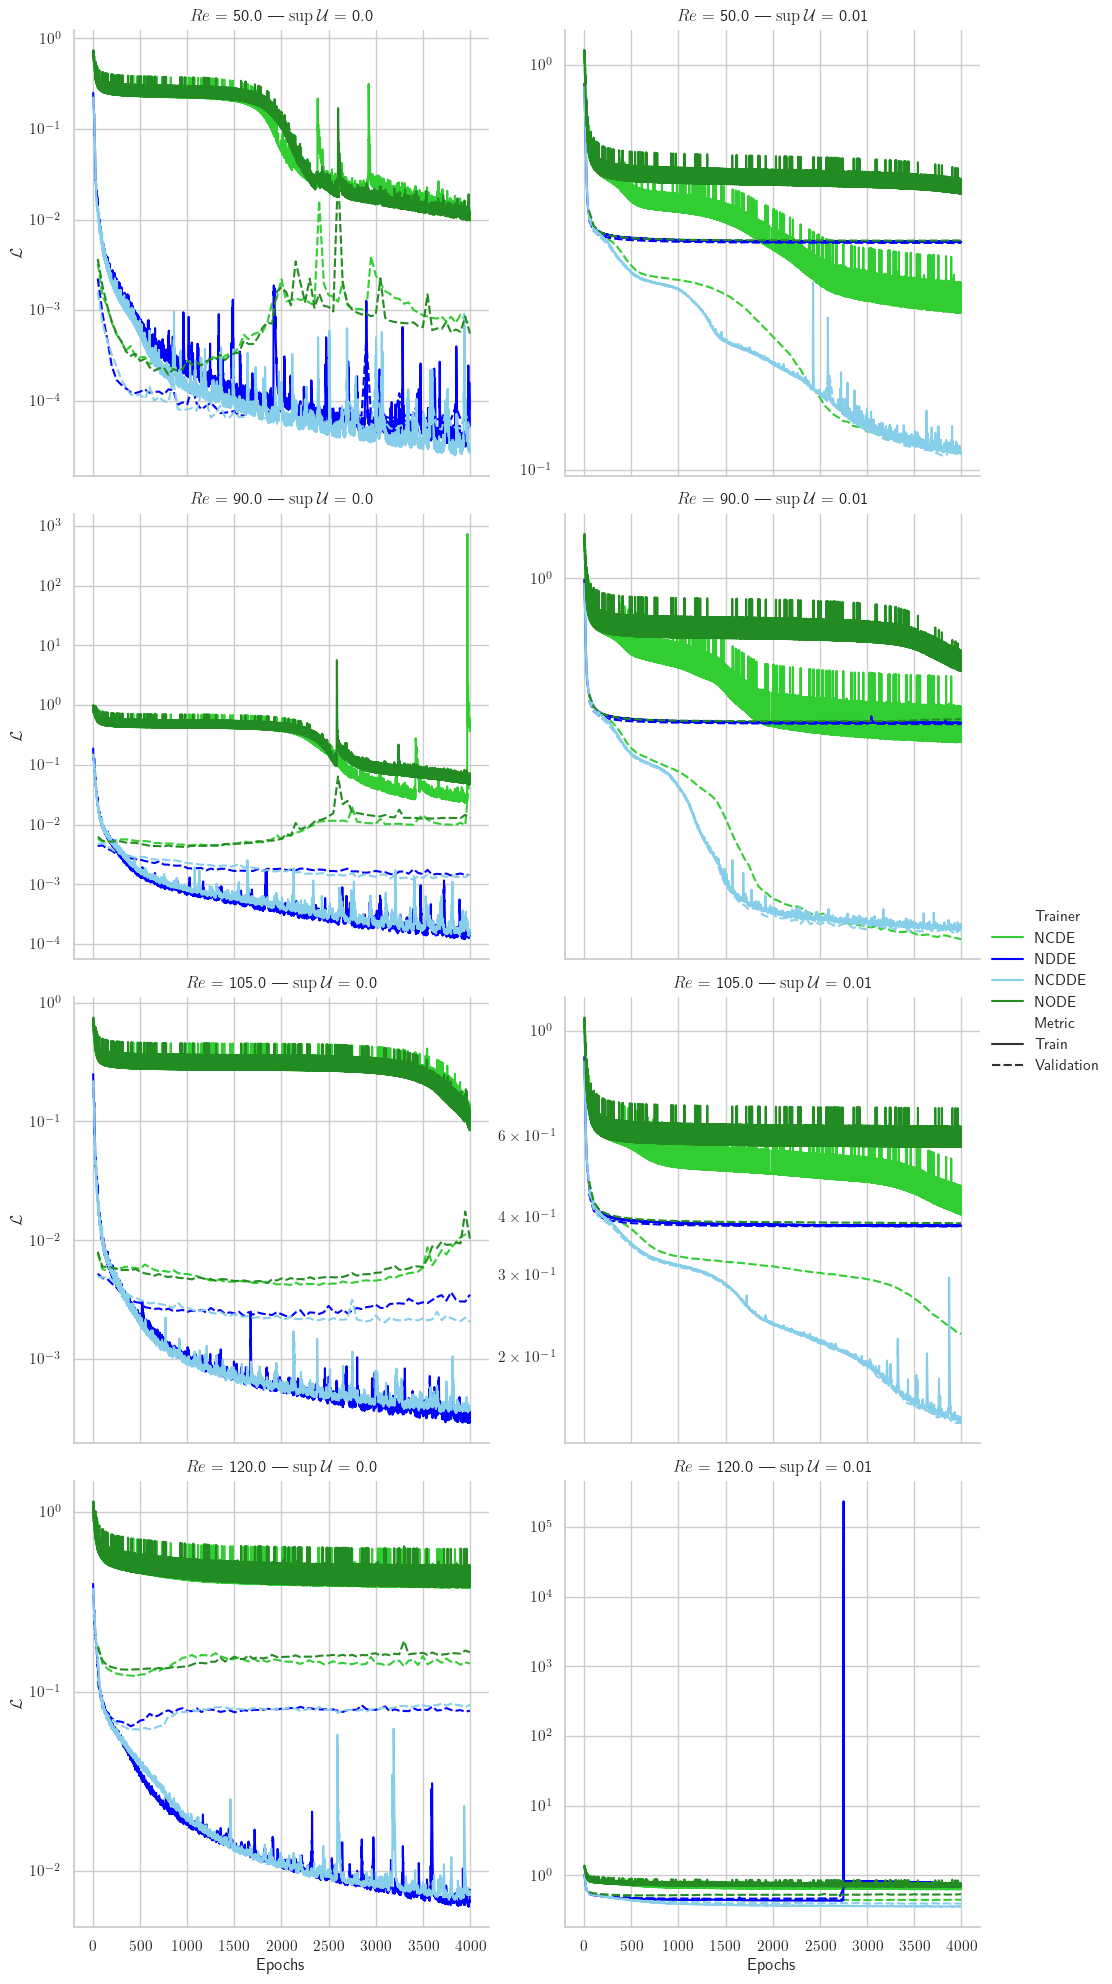

COLUMN VALUE: cavity


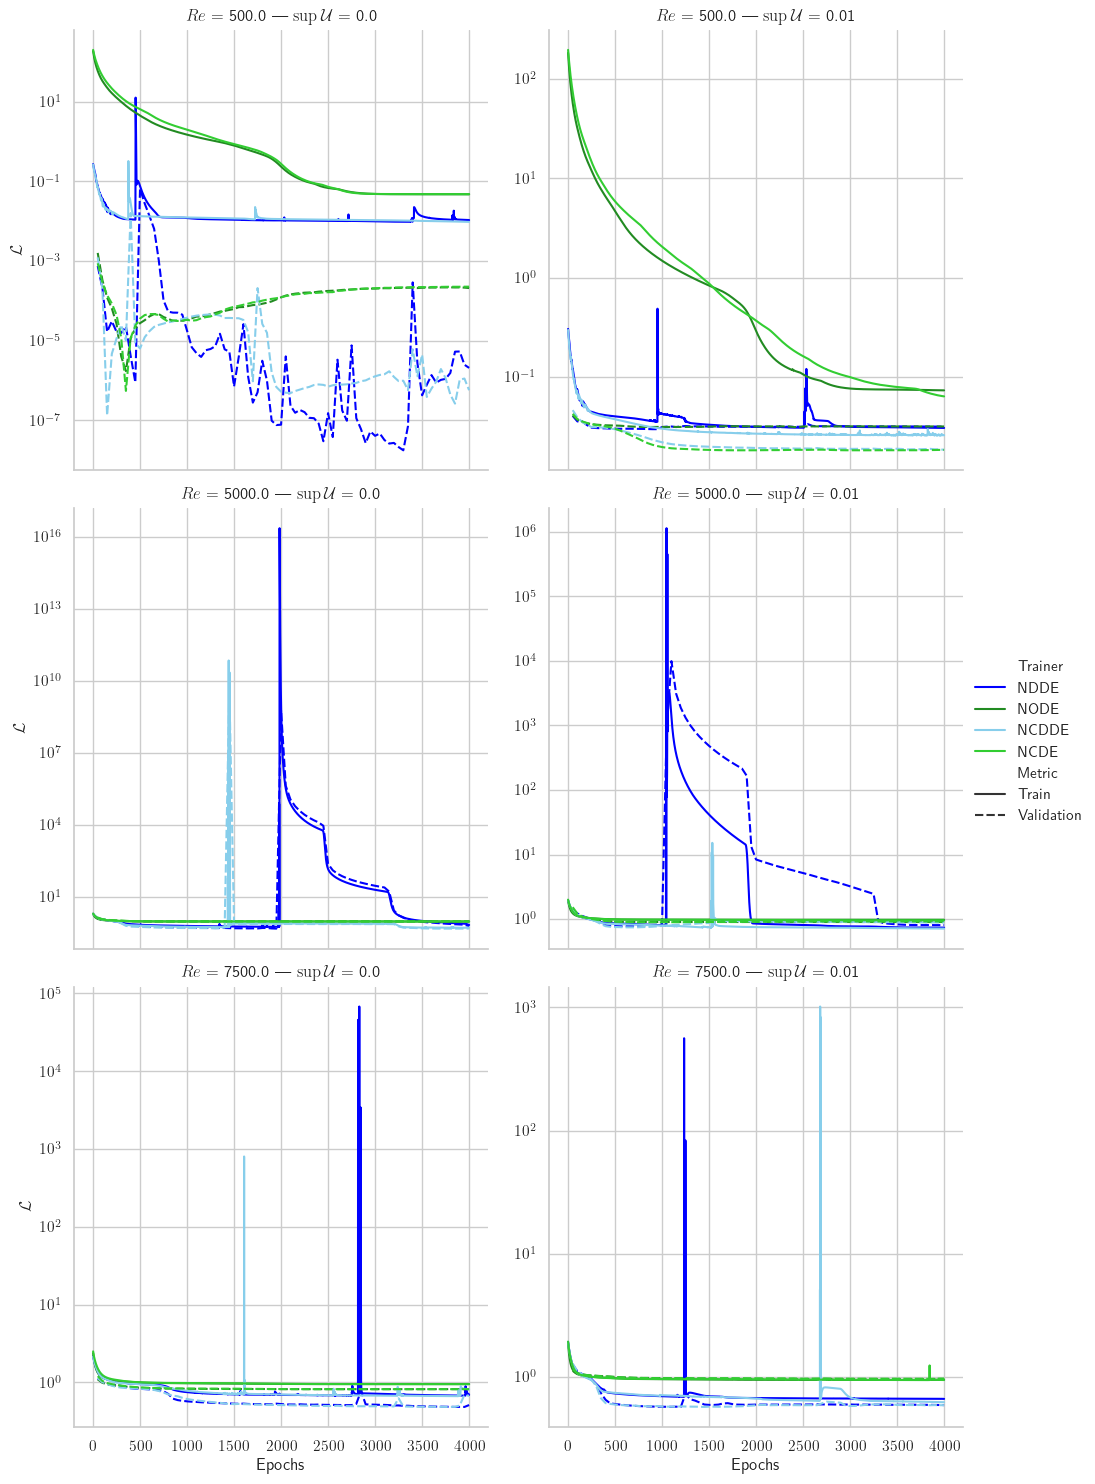

COLUMN VALUE: cylinder


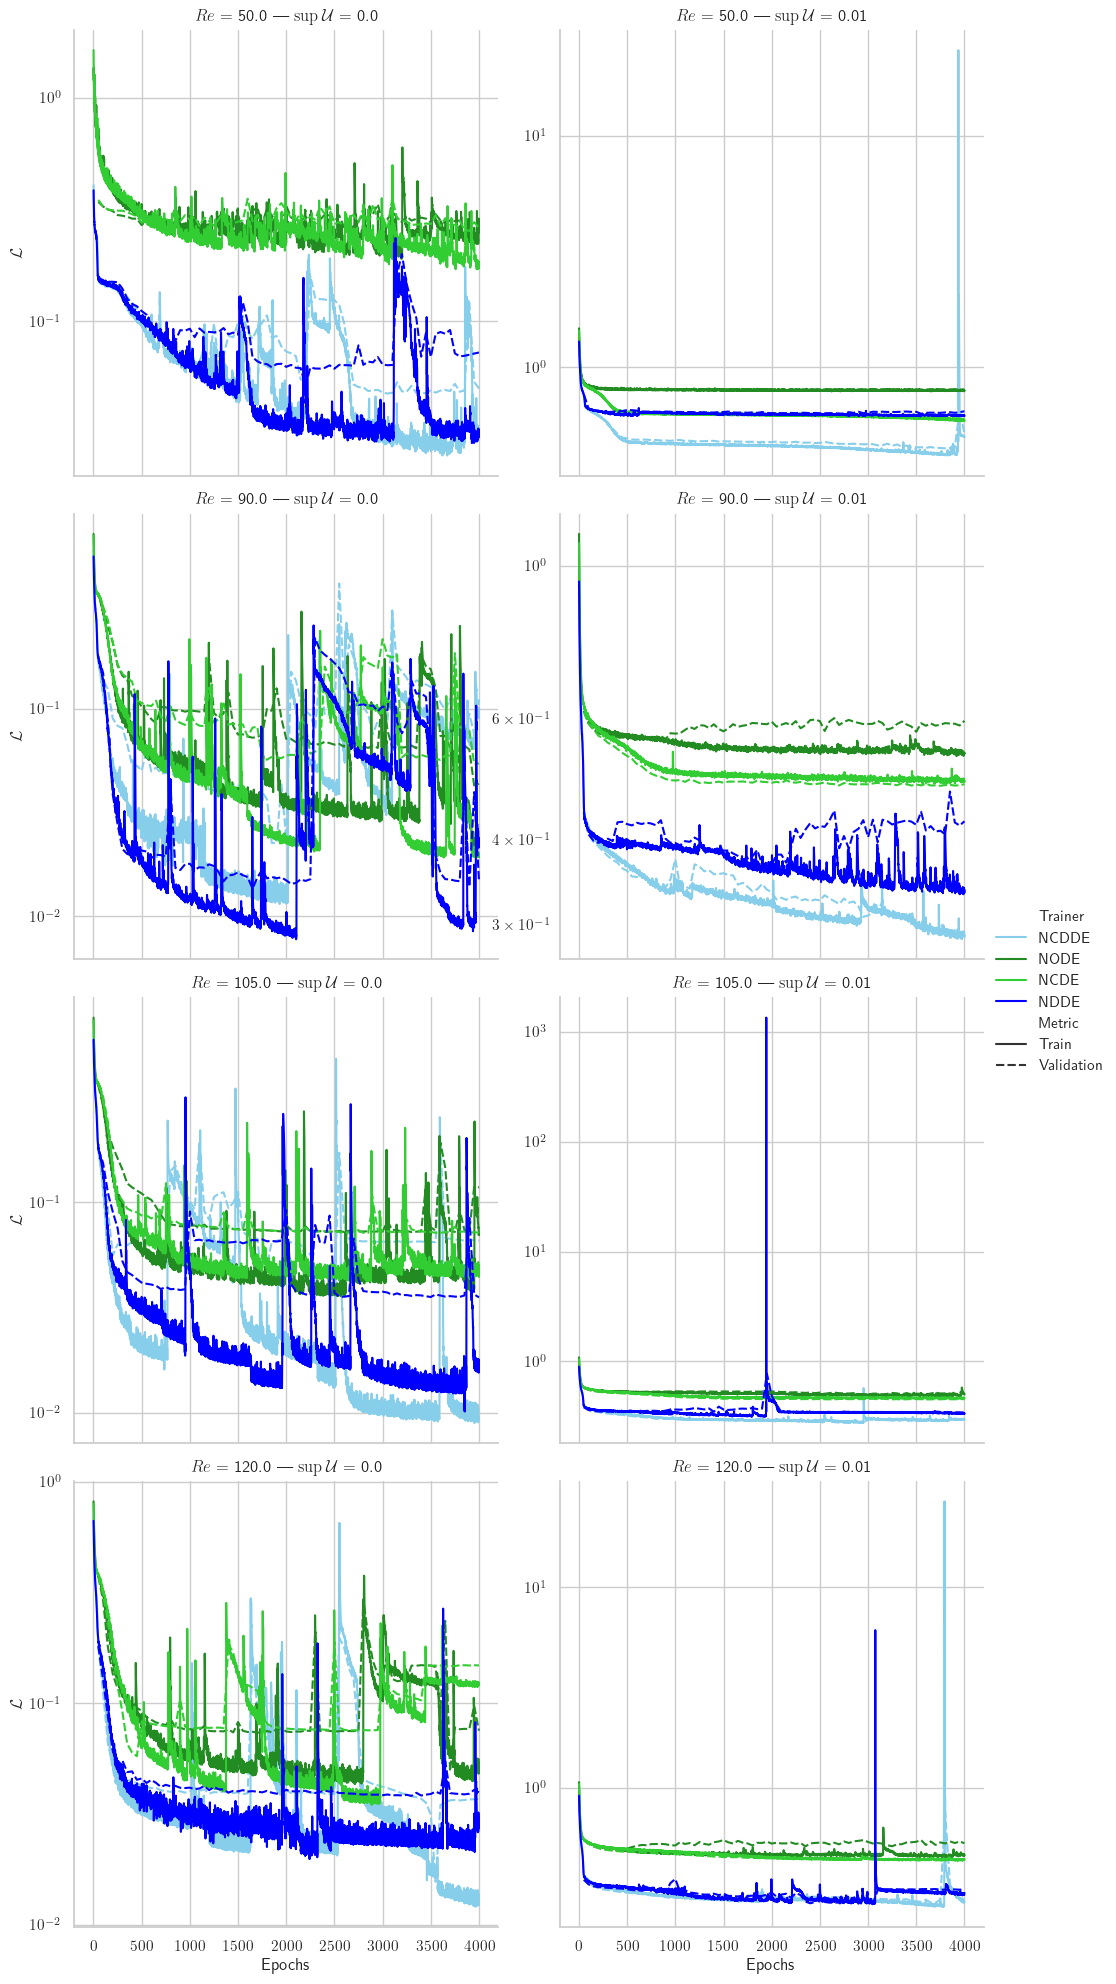

In [27]:
# plt.style.use('data/matplotlib_config/stylesheet.mplstyle')

list_unique_values_column_to_loop_over = df_all_data[NAME_COLUMN_TO_LOOP_OVER].unique()
plt.style.use("data/matplotlib_config/stylesheet.mplstyle")

# Plot a seaborn relplot
sns.set_theme(
    style="whitegrid",
    font="sans-serif",
    # rc={"figure.figsize": FIG_SIZE}
)

for column_value in list_unique_values_column_to_loop_over:
    print(f"COLUMN VALUE: {column_value}")

    df_sns = (
        df_all_data.loc[df_all_data[NAME_COLUMN_TO_LOOP_OVER] == column_value]
        .loc[df_all_data.metric.str.contains("loss")]
        .rename(columns=DICT_COL_DISPLAY_NAME)
        .replace(DICT_VALUE_DISPLAY_NAME)
        .sample(frac=1)
    )

    g = sns.relplot(
        data=df_sns,
        x=DICT_COL_DISPLAY_NAME["step"],
        y=DICT_COL_DISPLAY_NAME["value"],
        style=DICT_COL_DISPLAY_NAME["metric"],
        kind="line",
        hue=DICT_COL_DISPLAY_NAME[NAME_SEABORN_HUE],
        row=DICT_COL_DISPLAY_NAME[NAME_SEABORN_ROW],
        # col="delay_obs",
        col=DICT_COL_DISPLAY_NAME[NAME_SEABORN_COLUMN],
        # no confidence interval
        errorbar=None,
        # No sharing of the y-axis
        facet_kws={
            "sharey": False,
        },
        palette=COLOR_PALETTE,
        # height=height,
        # aspect=aspect_ratio,
        # Set the figure size
    )
    # Y-scale is logarithmic
    g.set(yscale="log")
    # g.fig.set_figwidth(4.7)  # TODO: REMOVE
    # g.fig.set_figheight(3.5)
    # Save the plot as a pgf file and a png file
    g.savefig(
        f"./data/generated_figures/figure_losses_{column_value}.pgf", backend="pgf"
    )
    g.savefig(f"./data/generated_figures/figure_losses_{column_value}.png")
    plt.show()